# 05 - Error effects (paper Fig 7, 8, Table 3)

RT and error rate by problem (the paper's circle-grid figure), the
table-neighbor vs numeric-neighbor error classification, and the error-rate
regression against problem size.


In [1]:
# Data source toggle. The live backend DB has zero trial_results as of
# 2026-09 (see ../DATA_GAPS.md) -- this app just went public. Flip
# USE_SYNTHETIC to False once real rows exist; every cell below is written
# against the DataFrame shape returned by moravec_analysis.data, so nothing
# else needs to change.
USE_SYNTHETIC = True

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from moravec_analysis.data import load_trial_results
from moravec_analysis.features import add_all_derived_fields, filter_rt_outliers
from moravec_analysis.synth import generate_synthetic_trials

if USE_SYNTHETIC:
    raw = generate_synthetic_trials(n_users=400, trials_per_user=150, seed=7)
else:
    raw = load_trial_results()  # defaults to apps/backend/data/moravec.sqlite

df = add_all_derived_fields(raw)
print(f"{len(df):,} trials, {df.email_hash.nunique():,} users")
df.head()


61,859 trials, 400 users


,id,email_hash,level_number,category_codename,operands,answer,correct,time_exceeded,time_taken,played_at,...,has_five,op1_gt_op2,unordered_pair,presented_pair,is_rhyme_pair,presented_in_rhyme_order,is_rhyme_control_pair,presented_in_control_order,table_distance_1,numeric_distance_le_2
0,177529bc-adbf-4a57-a752-5d69466b375a,f6bd0410527d6ea9a1e60637a73f97679f49abea307385...,5,1d+1d,"[2, 2]",4,True,False,1783.132304,2026-08-26 16:06:24.275,...,False,False,"(2, 2)","(2, 2)",False,False,False,False,<NA>,<NA>
1,3a3a2f49-79d7-4bdb-9d5f-24dc63d9a07d,f6bd0410527d6ea9a1e60637a73f97679f49abea307385...,5,1dx1d,"[3, 7]",21,True,False,3248.066102,2026-08-26 10:19:56.252,...,False,False,"(3, 7)","(3, 7)",False,False,False,False,<NA>,<NA>
2,d0f68d66-61cc-481e-a0b1-5ce322668f82,f6bd0410527d6ea9a1e60637a73f97679f49abea307385...,4,1d+1d,"[8, 0]",8,True,False,1584.694315,2026-08-21 05:32:44.299,...,False,True,"(0, 8)","(8, 0)",False,False,False,False,<NA>,<NA>
3,669f3b09-4516-4756-8efa-f0e49ee22f03,f6bd0410527d6ea9a1e60637a73f97679f49abea307385...,1,1d+1d,"[4, 4]",8,True,False,1936.467264,2026-08-15 14:45:52.252,...,False,False,"(4, 4)","(4, 4)",False,False,False,False,<NA>,<NA>
4,6e8ea120-c7b2-4e1e-aa0a-8824bb4976f5,f6bd0410527d6ea9a1e60637a73f97679f49abea307385...,5,1dx1d,"[5, 5]",25,True,False,1939.174017,2026-08-18 17:28:00.207,...,True,False,"(5, 5)","(5, 5)",False,False,False,False,<NA>,<NA>


## RT and error rate per problem (paper Fig 7)

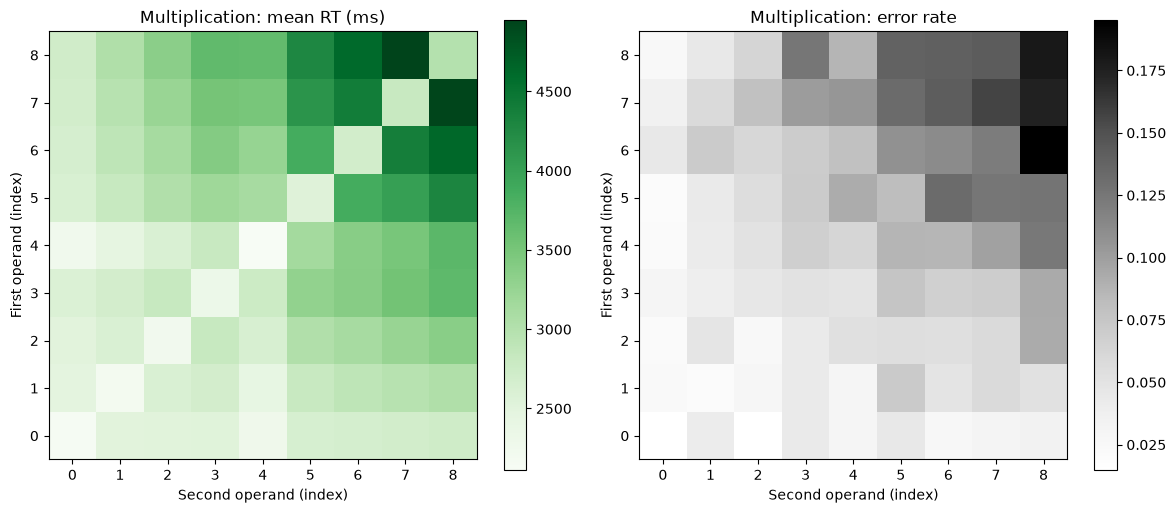

In [2]:
def problem_grid(data, category):
    sub = data[data["category_codename"] == category]
    rt = sub[sub["correct"]].groupby(["op1", "op2"])["time_taken"].mean().unstack()
    err = sub.groupby(["op1", "op2"])["correct"].apply(lambda s: 1 - s.mean()).unstack()
    return rt, err


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
rt, err = problem_grid(df, "1dx1d")
im0 = axes[0].imshow(rt, cmap="Greens", origin="lower")
axes[0].set_title("Multiplication: mean RT (ms)")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(err, cmap="Greys", origin="lower")
axes[1].set_title("Multiplication: error rate")
plt.colorbar(im1, ax=axes[1])
for ax in axes:
    ax.set_xlabel("Second operand (index)")
    ax.set_ylabel("First operand (index)")
plt.tight_layout()
plt.show()


## Table-neighbor vs numeric-neighbor errors (paper Fig 8)

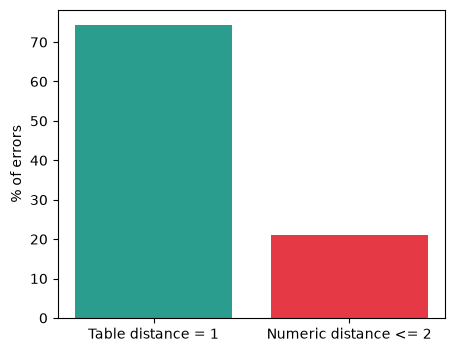

chi2=1389.8, p=3.49e-304


In [3]:
wrong_mult = df[(df["category_codename"] == "1dx1d") & (~df["correct"])]
table_neighbor_rate = wrong_mult["table_distance_1"].mean()
numeric_neighbor_rate = wrong_mult["numeric_distance_le_2"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Table distance = 1", "Numeric distance <= 2"],
       [table_neighbor_rate * 100, numeric_neighbor_rate * 100],
       color=["#2a9d8f", "#e63946"])
ax.set_ylabel("% of errors")
plt.show()

from scipy.stats import chi2_contingency

contingency = pd.DataFrame({
    "table_neighbor": [wrong_mult["table_distance_1"].sum(),
                        (~wrong_mult["table_distance_1"].astype(bool)).sum()],
    "numeric_neighbor": [wrong_mult["numeric_distance_le_2"].sum(),
                          (~wrong_mult["numeric_distance_le_2"].astype(bool)).sum()],
}, index=["is", "isn't"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"chi2={chi2:.1f}, p={p:.3g}")


## Error rate vs size (paper Table 3)

In [4]:
import statsmodels.formula.api as smf

def error_rate_model(data, category, is_tie, label):
    sub = data[(data["category_codename"] == category) & (data["is_tie"] == is_tie)].copy()
    sub["correct"] = sub["correct"].astype(int)
    model = smf.mixedlm("correct ~ product", data=sub, groups=sub["email_hash"])
    result = model.fit(reml=False)
    print(f"=== {label} ===")
    print(result.summary().tables[1].loc[["product"]])
    print()


error_rate_model(df, "1d+1d", False, "Addition, different operands")
error_rate_model(df, "1d+1d", True, "Addition, ties")
error_rate_model(df, "1dx1d", False, "Multiplication, different operands")
error_rate_model(df, "1dx1d", True, "Multiplication, ties")


/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_471355/2429616884.py:7: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  result = model.fit(reml=False)


/tmp/ipykernel_471355/2429616884.py:7: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result = model.fit(reml=False)


=== Addition, different operands ===
          Coef. Std.Err.        z  P>|z|  [0.025  0.975]
product  -0.001    0.000  -14.493  0.000  -0.001  -0.001



/tmp/ipykernel_471355/2429616884.py:7: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result = model.fit(reml=False)


=== Addition, ties ===
          Coef. Std.Err.       z  P>|z|  [0.025  0.975]
product  -0.000    0.000  -4.323  0.000  -0.001  -0.000



...

/tmp/ipykernel_471355/2429616884.py:7: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result = model.fit(reml=False)


=== Multiplication, different operands ===
          Coef. Std.Err.        z  P>|z|  [0.025  0.975]
product  -0.002    0.000  -26.074  0.000  -0.002  -0.002



/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_471355/2429616884.py:7: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  result = model.fit(reml=False)


/tmp/ipykernel_471355/2429616884.py:7: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result = model.fit(reml=False)


=== Multiplication, ties ===
          Coef. Std.Err.        z  P>|z|  [0.025  0.975]
product  -0.002    0.000  -13.119  0.000  -0.002  -0.002



Note: this models `correct` (0/1) with a linear mixed model, same as the paper's Table 3 (they regress error rate, so the sign here is flipped -- a negative `product` coefficient on `correct` corresponds to the paper's positive slope on error rate). A logistic mixed model (`smf.mixedlm` doesn't do logit; would need `statsmodels.genmod` or `GLMM` via `BinomialBayesMixedGLM`) is a closer match to how error *rates* are usually modeled -- worth revisiting once there's enough real data to care about that distinction.